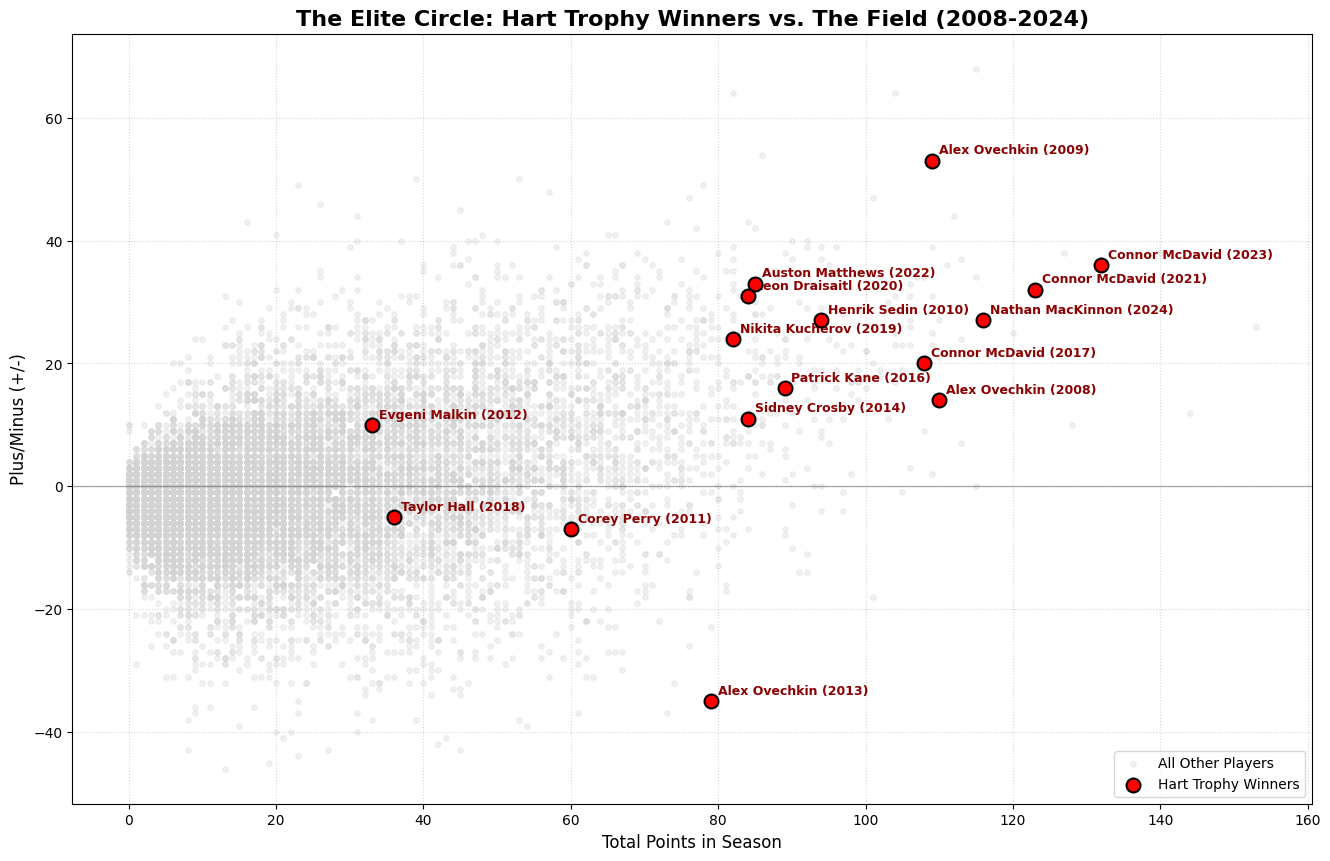

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata

# Function to handle special characters (e.g., Pastrňák -> Pastrnak)
def normalize_name(name):
    if not isinstance(name, str): return name
    return "".join(c for c in unicodedata.normalize('NFD', name) if unicodedata.category(c) != 'Mn')

# 1. Load both datasets
skaters = pd.read_csv('skaters_2008_to_2024.csv')
harts = pd.read_csv('/Users/ethanlee/Desktop/COGS 108/Group118_WI26/data/02-processed/hart_voting_2008_2025_processed.csv')

# 2. Calculate Plus/Minus (Logic: 5v5 + SHG - 5v5 - SHGA)
skaters['plus_val'] = 0
skaters.loc[skaters['situation'].isin(['5on5', '4on5', 'other']), 'plus_val'] = skaters['OnIce_F_goals']
skaters['minus_val'] = 0
skaters.loc[skaters['situation'].isin(['5on5', '5on4', 'other']), 'minus_val'] = skaters['OnIce_A_goals']

pm_data = skaters.groupby(['playerId', 'name', 'season']).agg({'plus_val': 'sum', 'minus_val': 'sum'}).reset_index()
pm_data['plus_minus'] = pm_data['plus_val'] - pm_data['minus_val']

# 3. Get Points (from the 'all' situation)
points_data = skaters[skaters['situation'] == 'all'][['playerId', 'name', 'season', 'I_F_points']].copy()
points_data.rename(columns={'I_F_points': 'total_points'}, inplace=True)

# Merge Stats
final_df = pd.merge(pm_data[['playerId', 'name', 'season', 'plus_minus']], 
                     points_data, on=['playerId', 'name', 'season'])

# 4. Filter and Merge Hart Winners
harts_winners = harts[harts['Place'] == 1].copy()
harts_winners['norm_player'] = harts_winners['Player'].apply(normalize_name)
final_df['norm_name'] = final_df['name'].apply(normalize_name)

# Find matching stats for the winners
hart_stats = pd.merge(harts_winners, final_df, 
                      left_on=['norm_player', 'Year'], 
                      right_on=['norm_name', 'season'])

# 5. Create the Visualization
plt.figure(figsize=(16, 10))

# Background: Plot all 15,000+ player-seasons in light grey
plt.scatter(final_df['total_points'], final_df['plus_minus'], 
            c='lightgrey', alpha=0.3, s=15, label='All Other Players')

# Foreground: Plot Hart Winners in Red
plt.scatter(hart_stats['total_points'], hart_stats['plus_minus'], 
            c='red', s=100, edgecolors='black', linewidth=1.5, zorder=5, label='Hart Trophy Winners')

# Add Labels for the Winners
for i, row in hart_stats.iterrows():
    plt.annotate(f"{row['name']} ({row['season']})", 
                 (row['total_points'], row['plus_minus']),
                 textcoords="offset points", xytext=(5,5), 
                 fontsize=9, fontweight='bold', color='darkred')

# Formatting
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.xlabel('Total Points in Season', fontsize=12)
plt.ylabel('Plus/Minus (+/-)', fontsize=12)
plt.title('The Elite Circle: Hart Trophy Winners vs. The Field (2008-2024)', fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')

plt.show()